# Detección de Anomalías en Transacciones con Tarjeta de Crédito
**Modelos:** Isolation Forest y Red Neuronal Autoencoder  
**Enfoque:** Aprendizaje no supervisado

## 1. Introducción y Planteamiento del Problema

El fraude con tarjeta de crédito es un problema de alta relevancia en sistemas financieros: ocurre con baja frecuencia pero con consecuencias económicas significativas. El objetivo de este proyecto es construir un sistema capaz de detectar transacciones fraudulentas de forma automática.

### Tipo de aprendizaje

El enfoque adoptado es no supervisado. Los modelos se entrenan exclusivamente con transacciones legítimas y aprenden a representar el comportamiento normal. Una transacción se considera sospechosa cuando se desvía significativamente de ese comportamiento aprendido.

Se aplican dos técnicas complementarias:
- **Aprendizaje basado en aislamiento** (Isolation Forest): identifica anomalías midiendo qué tan fácil es separar un punto del resto del dataset.
- **Aprendizaje basado en reconstrucción** (Autoencoder): identifica anomalías midiendo qué tan mal el modelo puede reconstruir una transacción que no sigue el patrón normal.

Se optó por aprendizaje no supervisado en lugar de clasificación supervisada por dos razones técnicas:

- **Desbalance extremo:** la proporción de transacciones fraudulentas es menor al 1%. Los clasificadores supervisados tienden a optimizar la clase mayoritaria, ignorando los fraudes.
- **Evolución del fraude:** los patrones de fraude cambian con el tiempo. Un modelo que aprende solo el comportamiento normal detecta cualquier desviación, incluyendo patrones de fraude nuevos no vistos en entrenamiento.

Las etiquetas de clase disponibles en el dataset (`is_fraud`) se reservan exclusivamente para evaluar el desempeño de los modelos, no para entrenarlos.

### Variables

- **Entrada:** características de la transacción derivadas del dataset. Las variables exactas que ingresan al modelo se definen en la sección 4, tras el análisis exploratorio y el preprocesamiento.
- **Salida (por modelo):** nivel de anomalía (un rango entre 0 y 1) y una etiqueta binaria (Normal / Anómalo).

## 2. Descripción del Dataset

El dataset utilizado es **Fraud_detection**, publicado en Kaggle por reemkasaab. Fue generado mediante la herramienta Sparkov Data Generation creada por Brandon Harris, que simula transacciones con tarjeta de crédito a partir de perfiles de comportamiento definidos por parámetros como frecuencia de transacciones, distribución de montos por categoría y patrones temporales.

El dataset cubre el período enero 2019 – diciembre 2020 e incluye transacciones simuladas de 1,000 clientes con 800 comerciantes distintos.

**Fuente:** https://www.kaggle.com/datasets/reemkasaab/fraud-detection  
**Licencia:** No especificada

Las dimensiones, distribución de clases, tipos de datos y valores nulos se verifican a continuación directamente sobre el archivo. El archivo cargado presenta 23 columnas: 22 variables del dataset más `Unnamed: 0`, que es el índice numérico del CSV original y no representa información del dominio.

In [1]:
from src.preprocessing import load_data, describe_dataset

df = load_data("data.csv")
describe_dataset(df)

Dimensiones: 1,852,394 filas × 23 columnas

Distribución de clases:
is_fraud
Normal    1842743
Fraude       9651
Name: count, dtype: int64

Porcentaje de fraude: 0.52%

Tipos de datos:
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

Valores nulos:
Ninguno

Primeras filas:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0



Resumen estadístico (variables numéricas):


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1852394.0,5.371934e+05,3.669110e+05,0.000000e+00,2.315490e+05,4.630980e+05,8.335758e+05,1.296674e+06
cc_num,1852394.0,4.173860e+17,1.309115e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1852394.0,7.006357e+01,1.592540e+02,1.000000e+00,9.640000e+00,4.745000e+01,8.310000e+01,2.894890e+04
zip,1852394.0,4.881326e+04,2.688185e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.992100e+04
lat,1852394.0,3.853931e+01,5.071470e+00,2.002710e+01,3.466890e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1852394.0,-9.022783e+01,1.374789e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1852394.0,8.864367e+04,3.014876e+05,2.300000e+01,7.410000e+02,2.443000e+03,2.032800e+04,2.906700e+06
unix_time,1852394.0,1.358674e+09,1.819508e+07,1.325376e+09,1.343017e+09,1.357089e+09,1.374581e+09,1.388534e+09
merch_lat,1852394.0,3.853898e+01,5.105604e+00,1.902742e+01,3.474012e+01,3.936890e+01,4.195626e+01,6.751027e+01
merch_long,1852394.0,-9.022794e+01,1.375969e+01,-1.666716e+02,-9.689944e+01,-8.744069e+01,-8.024511e+01,-6.695090e+01


### Limitaciones del dataset

- **Naturaleza sintética:** generado por simulación, por lo que puede no cubrir todos los patrones reales de fraude.
- **Licencia no especificada:** limita su uso fuera del ámbito educativo y analítico.
- **Período acotado:** dos años de datos pueden introducir sesgo temporal si los patrones de fraude han cambiado.
- **Sin descripción oficial de columnas:** el dataset no incluye un diccionario de datos formal.

## 3. Análisis Exploratorio (EDA)

Antes de modelar, se exploran los patrones del dataset para entender la naturaleza de los datos y fundamentar las decisiones de preprocesamiento. El EDA busca responder cinco preguntas clave:

1. ¿Qué tan desbalanceado está el dataset?
2. ¿Los montos de transacciones fraudulentas difieren de las normales?
3. ¿Hay categorías de comercio con mayor incidencia de fraude?
4. ¿El fraude sigue patrones temporales (hora del día, día de la semana)?
5. ¿Existe diferencia en la tasa de fraude entre géneros?

In [2]:
from src.eda import (
    plot_class_distribution, plot_amount_by_class, plot_fraud_by_category,
    plot_time_patterns, plot_fraud_by_gender
)

Distribución de clases:
  Normal: 1,842,743 (99.48%)
  Fraude: 9,651 (0.52%)


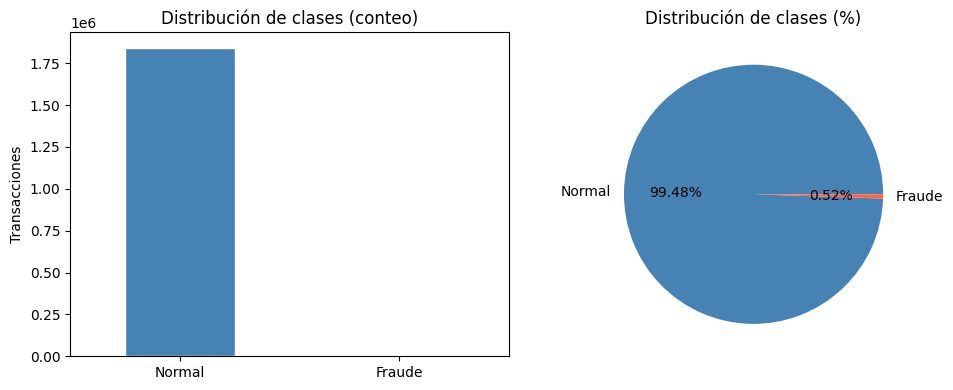

In [3]:
# 1. ¿Qué tan desbalanceado está el dataset?
plot_class_distribution(df)

El dataset presenta un desbalance extremo: el 99.48% de las transacciones son legítimas y apenas el 0.52% son fraudulentas. En el gráfico de barras la clase Fraude es prácticamente invisible, lo que ilustra visualmente por qué un clasificador supervisado entrenado sobre este dataset tendería a predecir siempre "Normal" y así alcanzar un 99.48% de exactitud, una métrica engañosa. Este desbalance es la motivación principal para adoptar un enfoque de detección de anomalías.

Estadísticas de monto por clase:
              count        mean         std   min      25%     50%      75%       max
is_fraud                                                                             
Normal    1842743.0   67.651278  153.548108  1.00    9.610   47.24   82.560  28948.90
Fraude       9651.0  530.661412  391.028873  1.06  240.075  390.00  902.365   1376.04


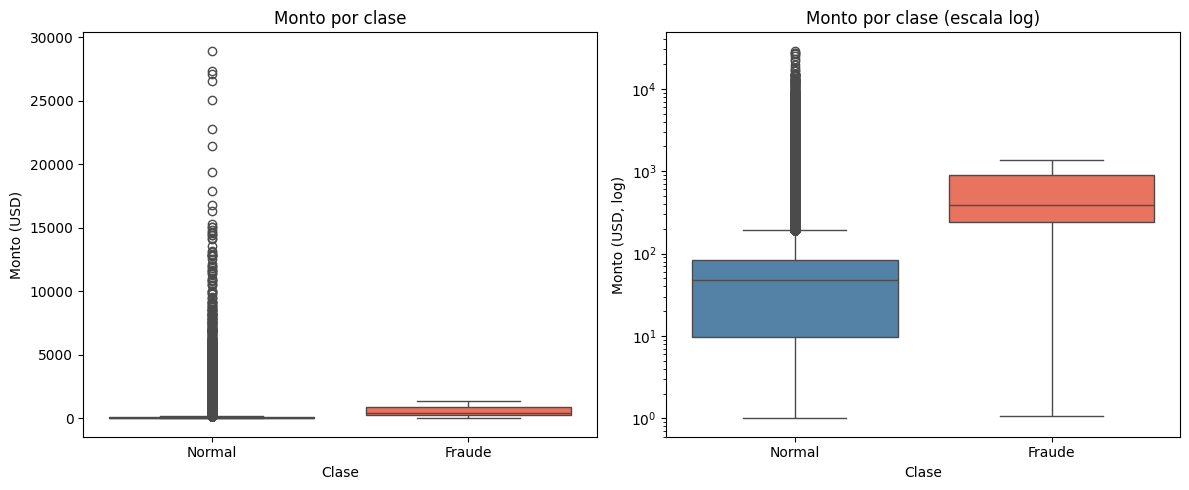

In [4]:
# 2. ¿Los montos de transacciones fraudulentas difieren de las normales?
plot_amount_by_class(df)

En escala lineal, los outliers de montos normales (hasta 28,948 dólares) dominan el eje y hacen que la caja de fraude sea casi invisible. Esto ilustra la necesidad de la escala logarítmica para analizar esta variable.

En escala logarítmica la diferencia es clara. La mediana de transacciones normales es 47.24 dólares, mientras que la de fraude es 390.00 dólares, aproximadamente 8 veces mayor. El 75% de las transacciones normales están por debajo de 82.56 dólares, valor que ni siquiera alcanza el percentil 25 del fraude (240.08 dólares). Esto significa que la gran mayoría de transacciones fraudulentas tienen montos superiores a casi toda la distribución normal.

Por otro lado, los valores más extremos del dataset (máximo 28,948 dólares) pertenecen a transacciones legítimas. El fraude tiene un máximo de 1,376.04 dólares, lo que indica que no apunta a montos máximos sino a un rango intermedio y acotado (240 a 902 dólares). El monto (`amt`) es una variable con poder discriminativo real y debe incluirse en el modelo.

Tasa de fraude por categoría (%):
category
shopping_net      1.59
misc_net          1.30
grocery_pos       1.26
shopping_pos      0.63
gas_transport     0.41
misc_pos          0.28
grocery_net       0.27
travel            0.27
personal_care     0.22
entertainment     0.22
kids_pets         0.19
food_dining       0.16
home              0.15
health_fitness    0.15


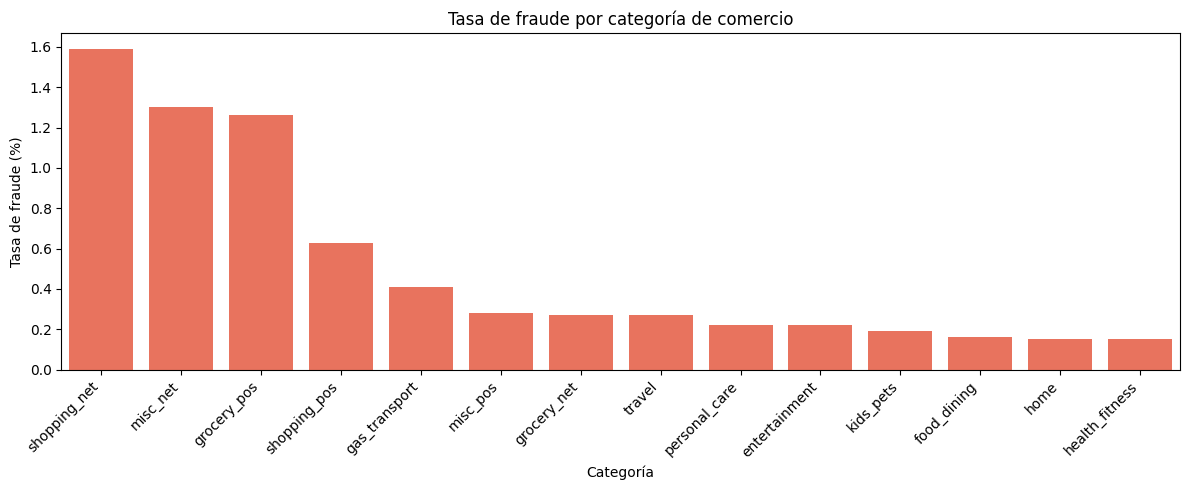

In [5]:
# 3. ¿Hay categorías de comercio con mayor incidencia de fraude?
plot_fraud_by_category(df)

La tasa de fraude varía significativamente entre categorías. `shopping_net` (compras minoristas en línea, 1.59%) tiene una tasa diez veces mayor que `home` y `health_fitness` (0.15%). Esa diferencia relativa entre categorías es lo que le da valor a esta variable para el modelo: no es que el fraude sea frecuente en términos absolutos, sino que la probabilidad de fraude cambia considerablemente dependiendo del tipo de comercio.

Dos de las tres categorías con mayor tasa son transacciones en línea (`shopping_net` y `misc_net`), lo que es coherente con que los canales digitales no requieren la presencia física de la tarjeta. La categoría (`category`) es una variable relevante para incluir en el modelo.

Tasa de fraude por hora:
hora
0     1.36
1     1.35
2     1.30
3     1.32
4     0.10
5     0.13
6     0.09
7     0.12
8     0.10
9     0.10
10    0.09
11    0.10
12    0.09
13    0.10
14    0.11
15    0.11
16    0.10
17    0.10
18    0.12
19    0.11
20    0.11
21    0.11
22    2.60
23    2.55

Tasa de fraude por día:
dia
Lunes        0.40
Martes       0.47
Miércoles    0.61
Jueves       0.64
Viernes      0.64
Sábado       0.57
Domingo      0.46


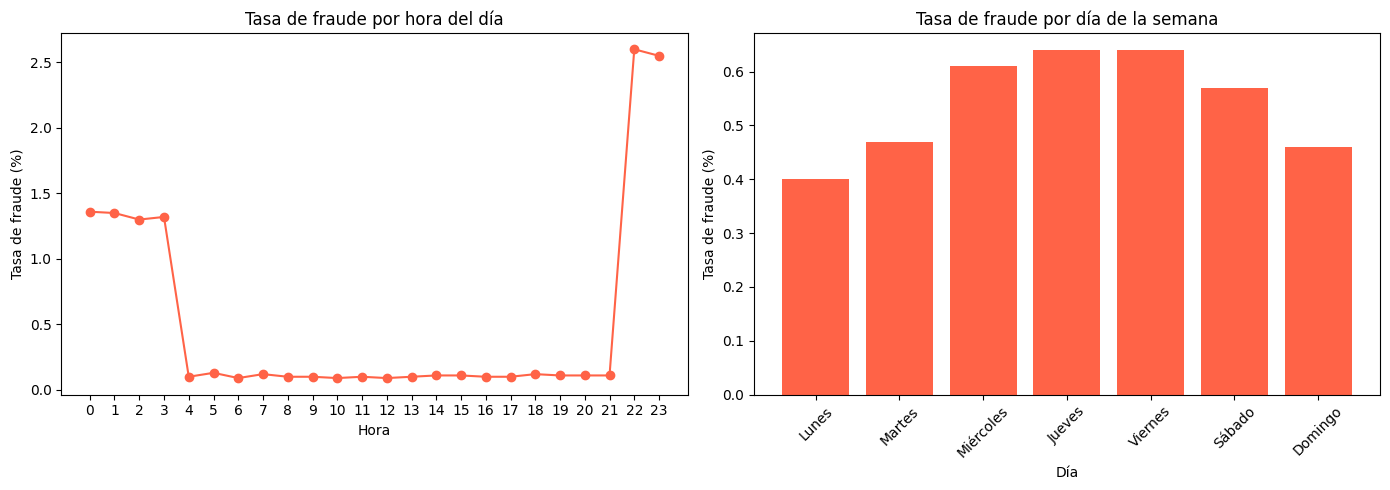

In [6]:
# 4. ¿El fraude sigue patrones temporales?
plot_time_patterns(df)

Las horas nocturnas (22:00, 23:00 y 0:00-3:00) concentran tasas entre 20 y 25 veces superiores al horario diurno. Esto sugiere que el fraude se ejecuta principalmente cuando los titulares están dormidos y es menos probable que reciban y reaccionen a alertas en tiempo real. La hora de la transacción es una variable con alto poder discriminativo y debe derivarse del campo `trans_date_trans_time` durante el preprocesamiento.

Por día de la semana la variación es menor y el patrón menos pronunciado, aunque sigue siendo una variable válida para incluir en el modelo.

Tasa de fraude por género:
   Género   Total  Fraudes  Tasa (%)
 Femenino 1014749     4899      0.48
Masculino  837645     4752      0.57


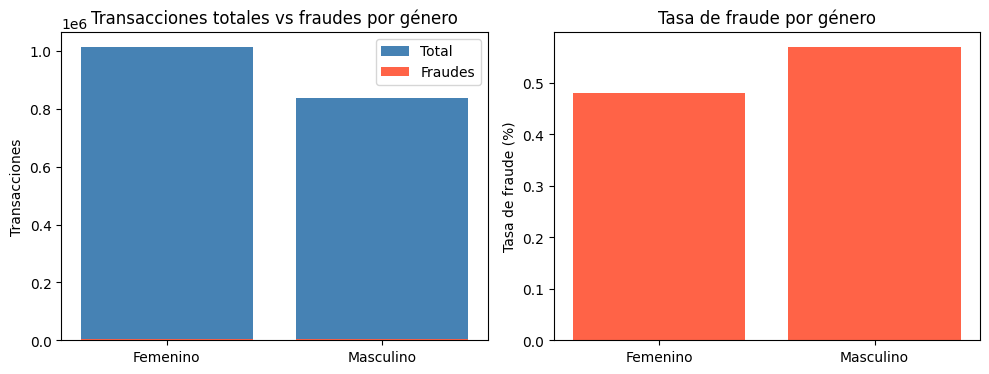

In [7]:
# 5. ¿Existe diferencia en la tasa de fraude entre géneros?
plot_fraud_by_gender(df)

La diferencia en la tasa de fraude entre géneros es mínima: 0.48% en transacciones de titulares femeninos y 0.57% en masculinos. A diferencia de la hora del día (diferencia de 20-25 veces) o la categoría del comercio (diferencia de 10 veces), el género aporta muy poco poder discriminativo al modelo.

Dado que la diferencia es marginal y que utilizar el género como variable predictiva introduce riesgos de sesgo de género, esta variable se descarta como entrada al modelo. Este punto se retoma en el análisis crítico.

## 4. Preprocesamiento

### Análisis de columnas numéricas

Min, max y rango por columna numérica:
                         min                          max                        rango
cc_num     60,416,207,185.00 4,992,346,398,065,154,048.00 4,992,346,337,648,947,200.00
unix_time   1,325,376,018.00             1,388,534,374.00                63,158,356.00
city_pop               23.00                 2,906,700.00                 2,906,677.00
Unnamed: 0              0.00                 1,296,674.00                 1,296,674.00
zip                 1,257.00                    99,921.00                    98,664.00
amt                     1.00                    28,948.90                    28,947.90
merch_long           -166.67                       -66.95                        99.72
long                 -165.67                       -67.95                        97.72
merch_lat              19.03                        67.51                        48.48
lat                    20.03                        66.69                        46.67
is_f

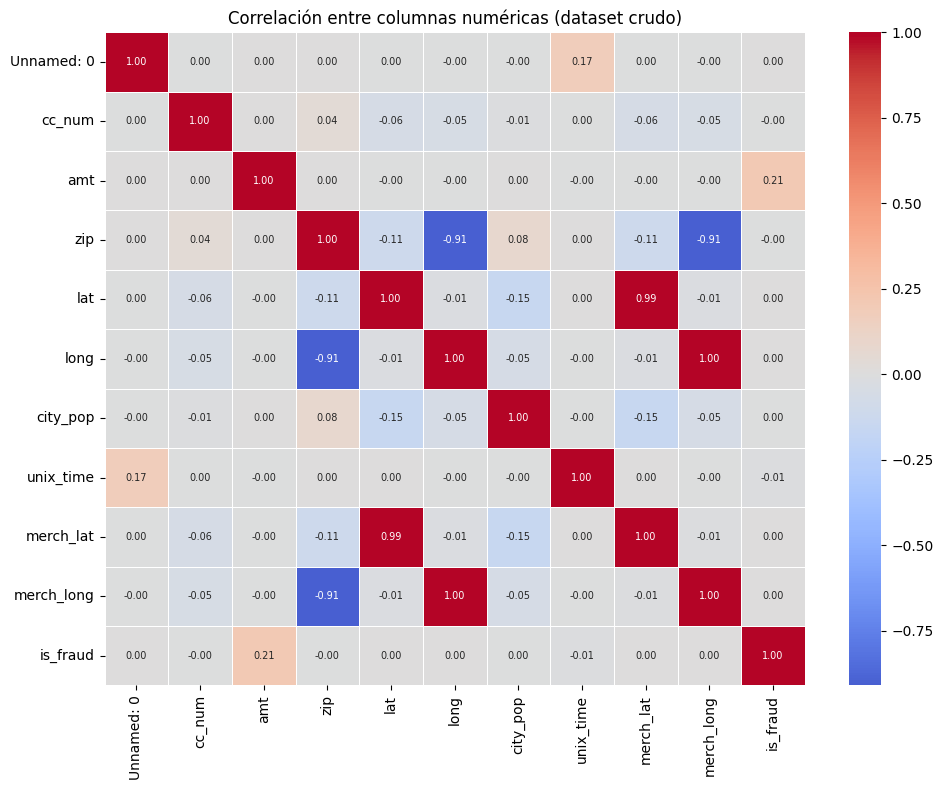

In [8]:
from src.eda import plot_numeric_analysis

plot_numeric_analysis(df)

La tabla de rangos y la matriz de correlación justifican qué columnas numéricas se eliminan:

**cc_num y Unnamed: 0:** rangos de 5×10¹⁸ y 1,296,674 respectivamente, confirman que son identificadores sin relación ordinal con el dominio. Se eliminan.

**unix_time:** correlaciona 0.17 con `Unnamed: 0`, lo que confirma su naturaleza de contador cronológico secuencial. La información temporal útil se extrae de `trans_date_trans_time` en el feature engineering. Se elimina.

**zip:** correlaciona -0.91 con `long` y -0.91 con `merch_long`. El código postal está prácticamente determinado por la longitud geográfica, por lo que no aporta información adicional a las coordenadas. Se elimina.

**Coordenadas (lat, long, merch_lat, merch_long):** `lat` y `merch_lat` correlacionan 0.99; `long` y `merch_long` correlacionan 1.00. Incluirlas por separado sería redundante. Se combinan en la variable `distancia` durante el feature engineering y luego se descartan.

### Análisis de columnas de texto

Cardinalidad de columnas de texto (valores únicos):
trans_num                1852394
trans_date_trans_time    1819551
street                       999
dob                          984
city                         906
merchant                     693
job                          497
last                         486
first                        355
state                         51
category                      14
gender                         2


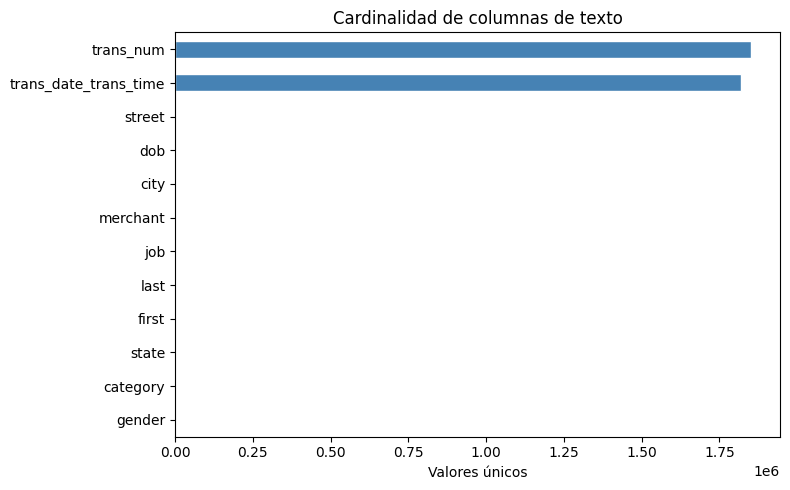

In [9]:
from src.eda import plot_text_analysis

plot_text_analysis(df)

La cardinalidad de cada columna justifica las decisiones de eliminación:

**`trans_num`:** 1,852,394 valores únicos, exactamente igual al número de filas. Identificador único por transacción. Se elimina.

**`trans_date_trans_time`:** 1,819,551 valores únicos. Su alta cardinalidad confirma que no puede usarse directamente como categórica. La información útil (hora, día de la semana) se extrae en el feature engineering y la columna original se descarta.

**`street`, `first`, `last`:** cardinalidades de 999, 355 y 486, consistentes con los 1,000 clientes del dataset. Son datos personales identificables sin señal predictiva. Se eliminan.

**`dob`:** 984 valores únicos, uno por cliente aproximadamente. No puede usarse como categórica ni como numérica directamente. Se transforma en la variable `edad` durante el feature engineering y luego se descarta.

**`merchant`:** 693 valores únicos, coherente con los 800 comerciantes del dataset. Cardinalidad demasiado alta para codificación directa. La variable `category` (14 valores) ya captura el tipo de negocio, que es la información relevante. Se elimina.

**`city` y `state`:** 906 y 51 valores únicos. La ubicación geográfica queda capturada con mayor precisión por las coordenadas, de las que se derivará `distancia`. Se eliminan.

**`job`:** 497 valores únicos, cardinalidad alta sin vínculo directo con el patrón de fraude. Se elimina.

**`gender`:** 2 valores. Su eliminación fue justificada en el EDA por diferencia de 0.09 puntos porcentuales en tasa de fraude entre géneros.

### Limpieza

In [10]:
from src.preprocessing import clean_data

df_clean = clean_data(df)
print(f"Columnas tras limpieza ({df_clean.shape[1]}): {list(df_clean.columns)}")

Columnas tras limpieza (10): ['trans_date_trans_time', 'category', 'amt', 'lat', 'long', 'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud']


### Feature Engineering

Se crean variables derivadas que capturan información estructurada a partir de columnas originales que no pueden usarse directamente como numéricas:

- **hora** y **dia_semana**: extraídos de `trans_date_trans_time`. El EDA mostró que la hora es la variable con mayor poder discriminativo del dataset (tasa de fraude 20-25 veces mayor en horario nocturno).
- **edad**: calculada a partir de `dob` usando como referencia el 2021-01-01 (día después al cierre del dataset). La edad del titular puede estar correlacionada con perfiles de comportamiento distintos.
- **distancia**: distancia en kilómetros entre la ubicación del titular (`lat`, `long`) y la del comercio (`merch_lat`, `merch_long`), calculada con la fórmula de Haversine. Una distancia inusualmente alta puede indicar que la tarjeta se está usando lejos de su titular.
- **`cat_*`**: codificación one-hot de la categoría del comercio (14 columnas binarias). El EDA mostró diferencias de hasta 10 veces en la tasa de fraude entre categorías.

Las columnas originales de las que se derivan estas features se descartan tras la transformación.

In [11]:
from src.preprocessing import feature_engineering

df_feat = feature_engineering(df_clean)
print(f"Columnas tras feature engineering ({df_feat.shape[1]}): {list(df_feat.columns)}")

Columnas tras feature engineering (21): ['amt', 'city_pop', 'is_fraud', 'hora', 'dia_semana', 'edad', 'distancia', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel']


### Escala y correlación de las features

Con el dataset ya limpio y transformado se analiza el rango de cada variable y las correlaciones entre ellas. El rango determina si las escalas son comparables entre sí o si se requiere normalización. Las correlaciones detectan si algún par de features es redundante.

Min, max y rango por variable numérica:
                     min          max        rango
city_pop           23.00 2,906,700.00 2,906,677.00
amt                 1.00    28,948.90    28,947.90
distancia           0.02       152.12       152.09
edad               15.00        96.00        81.00
hora                0.00        23.00        23.00
dia_semana          0.00         6.00         6.00
cat_entertainment   0.00         1.00         1.00
cat_food_dining     0.00         1.00         1.00
cat_gas_transport   0.00         1.00         1.00
cat_grocery_net     0.00         1.00         1.00
cat_grocery_pos     0.00         1.00         1.00
cat_health_fitness  0.00         1.00         1.00
cat_home            0.00         1.00         1.00
cat_kids_pets       0.00         1.00         1.00
cat_misc_net        0.00         1.00         1.00
cat_misc_pos        0.00         1.00         1.00
cat_personal_care   0.00         1.00         1.00
cat_shopping_net    0.00         1.00     

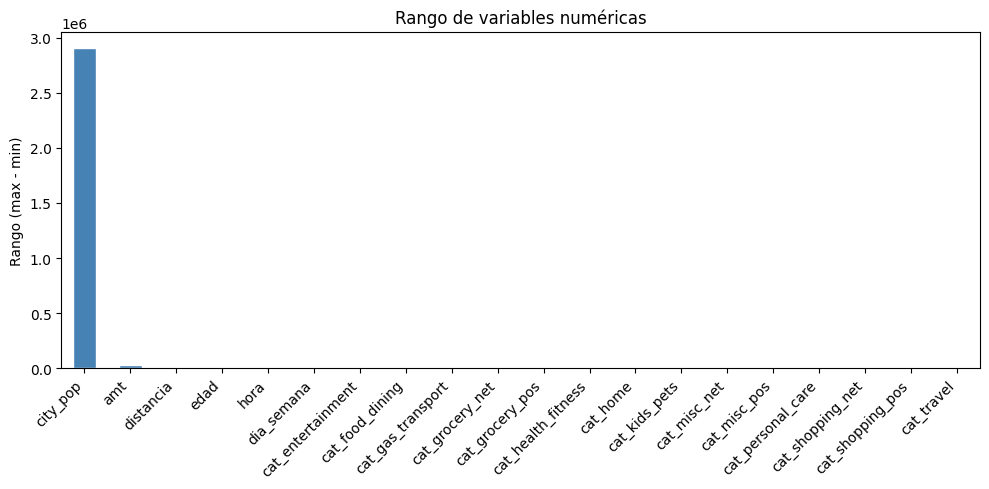

In [12]:
from src.eda import plot_ranges, plot_correlation_matrix

plot_ranges(df_feat.drop(columns=['is_fraud']))

Las escalas entre variables son radicalmente distintas: `city_pop` tiene un rango de casi 2.9 millones, `amt` de 28,948, `distancia` de 152 km, `edad` de 81 años, `hora` de 23 y `dia_semana` de 6. Las variables `cat_*` son binarias con rango 1.

Sin escalado, variables como `city_pop` dominarían los cálculos del modelo por magnitud, no por relevancia. El escalado con `StandardScaler` es necesario para que todas las features contribuyan en igualdad de condiciones.

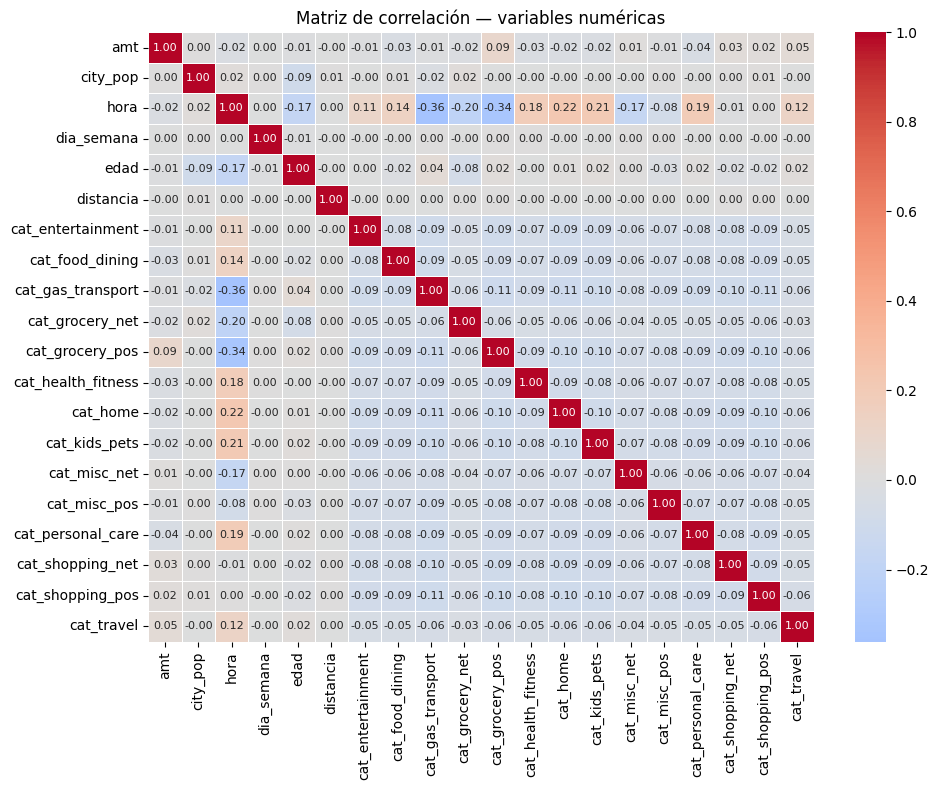

In [13]:
plot_correlation_matrix(df_feat)

Ningún par de features independientes supera una correlación absoluta de 0.40, lo que indica que no hay redundancia significativa entre las variables resultantes del preprocesamiento.

Las correlaciones más fuertes en valor absoluto involucran a `hora` con algunas categorías: -0.36 con `cat_gas_transport` y -0.34 con `cat_grocery_pos`. El signo negativo indica que esas categorías tienden a ocurrir en horario diurno (cuando `hora` es baja), lo cual refleja una relación real del dominio, no redundancia. Ambas variables aportan información distinta al modelo.

Las correlaciones negativas entre variables `cat_*` entre sí son esperadas y no representan un problema: son el resultado matemático de la codificación one-hot sobre una variable mutuamente excluyente.

`amt`, `distancia`, `city_pop`, `dia_semana` y `edad` muestran correlaciones cercanas a cero con todo lo demás, confirmando que cada una aporta una dimensión de información independiente.

### División train/test y escalado

El conjunto se divide de forma estratificada (80% train, 20% test) para preservar la proporción de fraude. El conjunto de entrenamiento retiene únicamente transacciones normales (`is_fraud == 0`), acorde al enfoque no supervisado: los modelos aprenden el comportamiento legítimo sin ver ejemplos de fraude. Las etiquetas (`y_test`) se reservan para la evaluación en la sección 7.

El `StandardScaler` se ajusta exclusivamente sobre `X_train` y luego se aplica a ambos conjuntos. Ajustarlo también sobre el test introduciría data leakage: el modelo de escalado habría "visto" el test antes de la evaluación.

In [14]:
from src.preprocessing import split_data, scale_data

X_train, X_test, y_test = split_data(df_feat)
X_train_sc, X_test_sc, scaler = scale_data(X_train, X_test)

print(f"Train (solo normales): {X_train_sc.shape}")
print(f"Test:  {X_test_sc.shape},  Fraudes en test: {y_test.sum()}")

Train (solo normales): (1474194, 20)
Test:  (370479, 20),  Fraudes en test: 1930


## 5. Modelo 1 — Isolation Forest

## 6. Modelo 2 — Autoencoder (Red Neuronal)

## 7. Evaluación Comparativa

## 8. Sistema Interactivo

## 9. Análisis Crítico

## 10. Conclusiones